In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# embed_df.parquet, split_train.parquet, split_val.parquet, split_test.parquet
uploaded = files.upload()

embed_df = pd.read_parquet("embed_df.parquet")
df_train = pd.read_parquet("split_train.parquet")
df_val   = pd.read_parquet("split_val.parquet")
df_test  = pd.read_parquet("split_test.parquet")

KEYWORDS = df_train["keyword"].unique()
CITIES   = df_train["city"].unique()
SEQ_LEN  = 6
HORIZONS = [1, 2, 3]
EMB_COLS = [c for c in embed_df.columns if c.startswith("emb_")]

print(f"Embedding shape: {embed_df.shape}")
print(f"Embedding columns: {len(EMB_COLS)}")
print(f"Train: {len(df_train)} rows")
print(f"Val:   {len(df_val)} rows")
print(f"Test:  {len(df_test)} rows")

Saving embed_df.parquet to embed_df.parquet
Saving split_test.parquet to split_test.parquet
Saving split_val.parquet to split_val.parquet
Saving split_train.parquet to split_train.parquet
Embedding shape: (2818, 773)
Embedding columns: 768
Train: 5112 rows
Val:   216 rows
Test:  1116 rows


In [2]:
!pip install torch --quiet

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
def build_multimodal_sequences(trend_df, embed_df, emb_cols, seq_len, horizons):
    """
    For each city+keyword, build sequences of:
    - X_trend: (seq_len,) past trend scores
    - X_emb:   (768,) DistilBERT embedding at the prediction month
    - y:       scalar trend score at t+horizon
    """
    X_trend_all, X_emb_all, y_all, meta = [], [], [], []

    # Build a lookup for embeddings: (city, month, keyword) -> embedding vector
    emb_lookup = {}
    for _, row in embed_df.iterrows():
        key = (row["city"], row["month"], row["keyword"])
        emb_lookup[key] = row[emb_cols].values.astype(np.float32)

    for city in trend_df["city"].unique():
        for kw in trend_df["keyword"].unique():
            series = (
                trend_df[(trend_df["city"] == city) & (trend_df["keyword"] == kw)]
                .sort_values("month")
                .reset_index(drop=True)
            )
            values = series["trend_score_smooth"].values
            months = series["month"].values

            for i in range(seq_len, len(values)):
                x_seq = values[i - seq_len:i]

                for h in horizons:
                    target_idx = i + h - 1
                    if target_idx >= len(values):
                        continue

                    target_month = months[target_idx]
                    emb_key = (city, target_month, kw)

                    # Skip if no embedding available for this month
                    if emb_key not in emb_lookup:
                        continue

                    X_trend_all.append(x_seq)
                    X_emb_all.append(emb_lookup[emb_key])
                    y_all.append(values[target_idx])
                    meta.append({
                        "city": city,
                        "keyword": kw,
                        "horizon": h,
                        "month": target_month
                    })

    return (
        np.array(X_trend_all, dtype=np.float32),
        np.array(X_emb_all,   dtype=np.float32),
        np.array(y_all,       dtype=np.float32),
        meta
    )

# Use same train/val split strategy as LSTM notebook
df_trainval  = pd.concat([df_train, df_val]).sort_values("month")
all_months   = sorted(df_trainval["month"].unique())
split_idx    = int(len(all_months) * 0.8)
val_cutoff   = all_months[split_idx]

df_tr = df_trainval[df_trainval["month"] <= val_cutoff]
df_vl = df_trainval[df_trainval["month"] > val_cutoff]

X_trend_train, X_emb_train, y_train_arr, meta_train = build_multimodal_sequences(df_tr,   embed_df, EMB_COLS, SEQ_LEN, HORIZONS)
X_trend_val,   X_emb_val,   y_val_arr,   meta_val   = build_multimodal_sequences(df_vl,   embed_df, EMB_COLS, SEQ_LEN, HORIZONS)
X_trend_test,  X_emb_test,  y_test_arr,  meta_test  = build_multimodal_sequences(df_test, embed_df, EMB_COLS, SEQ_LEN, HORIZONS)

print(f"Train sequences: {X_trend_train.shape}, embeddings: {X_emb_train.shape}")
print(f"Val sequences:   {X_trend_val.shape},   embeddings: {X_emb_val.shape}")
print(f"Test sequences:  {X_trend_test.shape},  embeddings: {X_emb_test.shape}")

Train sequences: (3849, 6), embeddings: (3849, 768)
Val sequences:   (1577, 6),   embeddings: (1577, 768)
Test sequences:  (2009, 6),  embeddings: (2009, 768)


In [4]:
class MultimodalTrendLSTM(nn.Module):
    def __init__(self, emb_dim=768, hidden_size=128, num_layers=2,
                 dropout=0.2, proj_dim=64):
        super().__init__()

        # LSTM processes the trend score sequence
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Project 768-dim BERT embedding down to proj_dim
        self.emb_proj = nn.Sequential(
            nn.Linear(emb_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Final prediction head: LSTM output + projected embedding
        self.fc = nn.Sequential(
            nn.Linear(hidden_size + proj_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_trend, x_emb):
        # x_trend: (batch, seq_len, 1)
        # x_emb:   (batch, 768)
        lstm_out, _ = self.lstm(x_trend)
        lstm_last   = lstm_out[:, -1, :]        # (batch, hidden_size)
        emb_proj    = self.emb_proj(x_emb)      # (batch, proj_dim)
        combined    = torch.cat([lstm_last, emb_proj], dim=1)
        return self.fc(combined).squeeze(-1)

model = MultimodalTrendLSTM(
    emb_dim=768, hidden_size=128, num_layers=2, dropout=0.2, proj_dim=64
).to(device)
print(model)

MultimodalTrendLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (emb_proj): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [9]:
# Prepare tensors
X_trend_tr_t = torch.tensor(X_trend_train).unsqueeze(-1).to(device)
X_emb_tr_t   = torch.tensor(X_emb_train).to(device)
y_tr_t       = torch.tensor(y_train_arr).to(device)

X_trend_vl_t = torch.tensor(X_trend_val).unsqueeze(-1).to(device)
X_emb_vl_t   = torch.tensor(X_emb_val).to(device)
y_vl_t       = torch.tensor(y_val_arr).to(device)

dataset   = TensorDataset(X_trend_tr_t, X_emb_tr_t, y_tr_t)
loader    = DataLoader(dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 100
best_val_loss    = float("inf")
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb_trend, xb_emb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb_trend, xb_emb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
    train_loss /= len(y_train_arr)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_trend_vl_t, X_emb_vl_t)
        val_loss = criterion(val_pred, y_vl_t).item()

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} --> Train Loss: {train_loss:.8f}, Val Loss: {val_loss:.8f}")

model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.8f}")

Epoch 10/100 --> Train Loss: 0.00000181, Val Loss: 0.00000087
Epoch 20/100 --> Train Loss: 0.00000166, Val Loss: 0.00000210
Epoch 30/100 --> Train Loss: 0.00000156, Val Loss: 0.00000246
Epoch 40/100 --> Train Loss: 0.00000149, Val Loss: 0.00000039
Epoch 50/100 --> Train Loss: 0.00000149, Val Loss: 0.00000119
Epoch 60/100 --> Train Loss: 0.00000145, Val Loss: 0.00000050
Epoch 70/100 --> Train Loss: 0.00000139, Val Loss: 0.00000042
Epoch 80/100 --> Train Loss: 0.00000153, Val Loss: 0.00000071
Epoch 90/100 --> Train Loss: 0.00000143, Val Loss: 0.00000034
Epoch 100/100 --> Train Loss: 0.00000134, Val Loss: 0.00000030

Best val loss: 0.00000030


In [6]:
from sklearn.metrics import mean_absolute_error

model.eval()
X_trend_te_t = torch.tensor(X_trend_test).unsqueeze(-1).to(device)
X_emb_te_t   = torch.tensor(X_emb_test).to(device)

with torch.no_grad():
    y_pred = model(X_trend_te_t, X_emb_te_t).cpu().numpy()

results_df = pd.DataFrame(meta_test)
results_df["actual"]    = y_test_arr
results_df["predicted"] = y_pred
results_df["abs_error"] = np.abs(y_test_arr - y_pred)

mae_by_horizon = (
    results_df.groupby("horizon")["abs_error"]
    .mean()
    .reset_index()
    .rename(columns={"abs_error": "MAE"})
)
print("Multimodal LSTM (BERT + Trend) MAE by Forecast Horizon:")
print(mae_by_horizon.to_string(index=False))

mae_by_keyword = (
    results_df.groupby(["keyword", "horizon"])["abs_error"]
    .mean()
    .unstack(level="horizon")
    .round(6)
)
print("\nMAE by keyword (columns = horizon):")
print(mae_by_keyword)

Multimodal LSTM (BERT + Trend) MAE by Forecast Horizon:
 horizon      MAE
       1 0.000755
       2 0.000792
       3 0.000823

MAE by keyword (columns = horizon):
horizon                      1         2         3
keyword                                           
birria                0.001698  0.001792  0.001884
birria tacos          0.001015  0.001073  0.001128
boba                  0.001100  0.001164  0.001241
charcuterie           0.000707  0.000742  0.000764
elote                 0.000380  0.000381  0.000372
korean fried chicken  0.000484  0.000501  0.000505
matcha                0.000578  0.000630  0.000681
shakshuka             0.000499  0.000522  0.000545
smash burger          0.000639  0.000616  0.000588
truffle fries         0.000440  0.000459  0.000482
tteokbokki            0.000485  0.000474  0.000474
wagyu                 0.000832  0.000841  0.000821


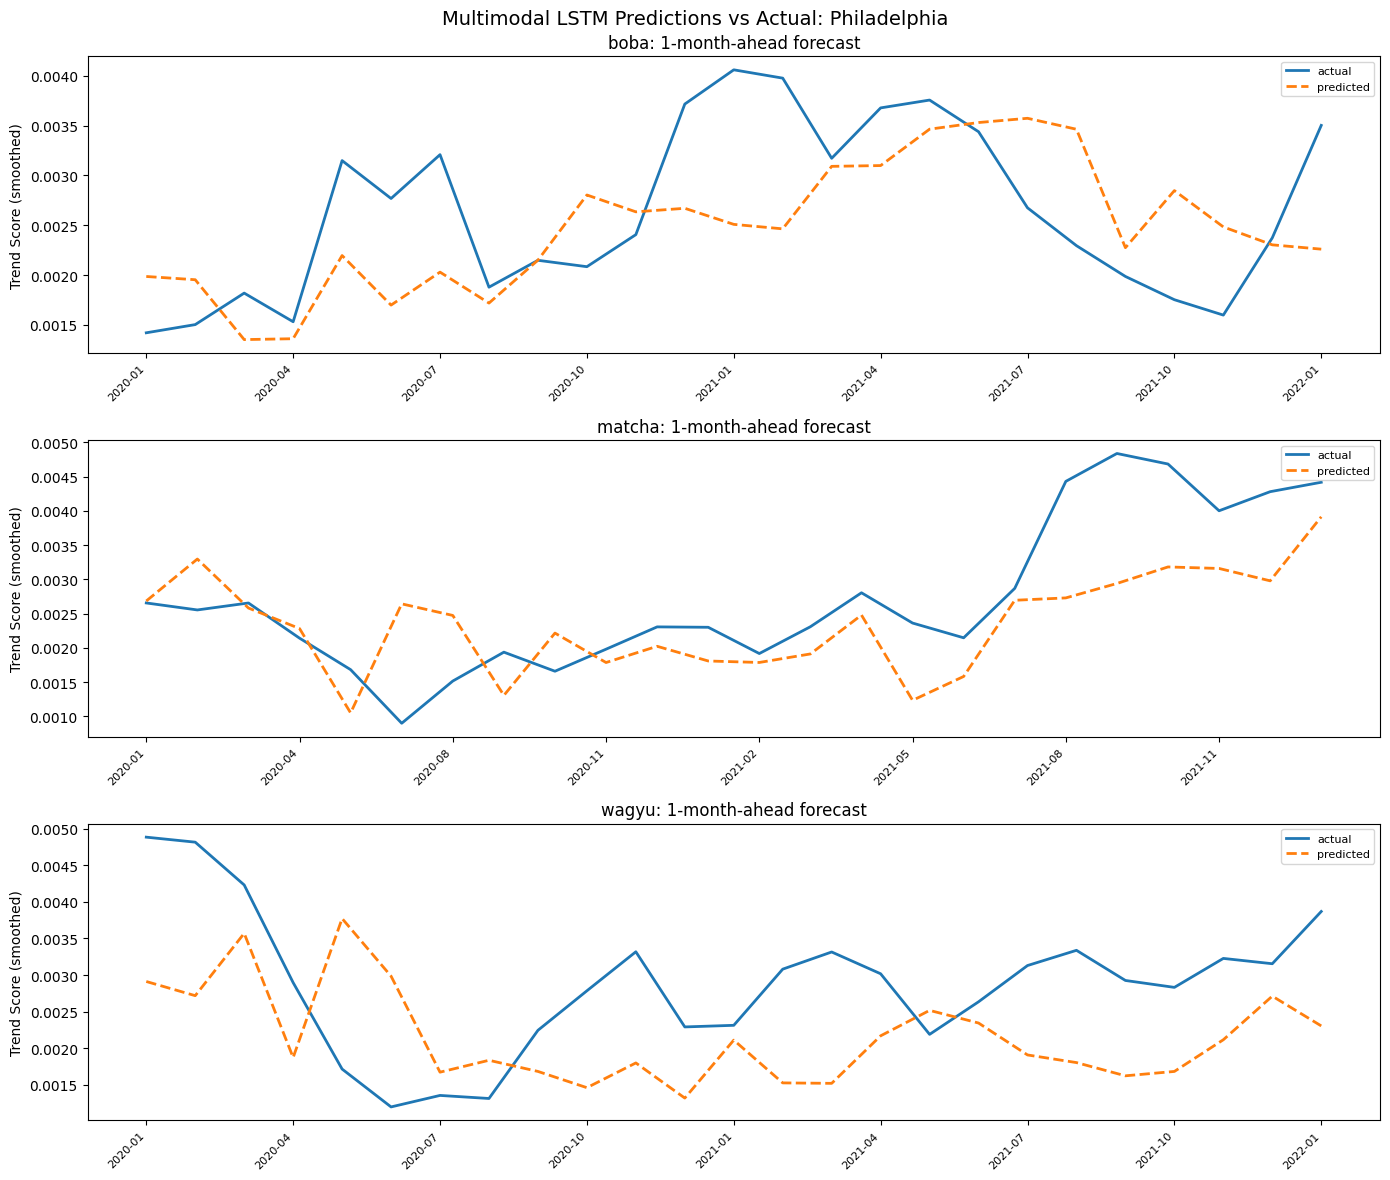

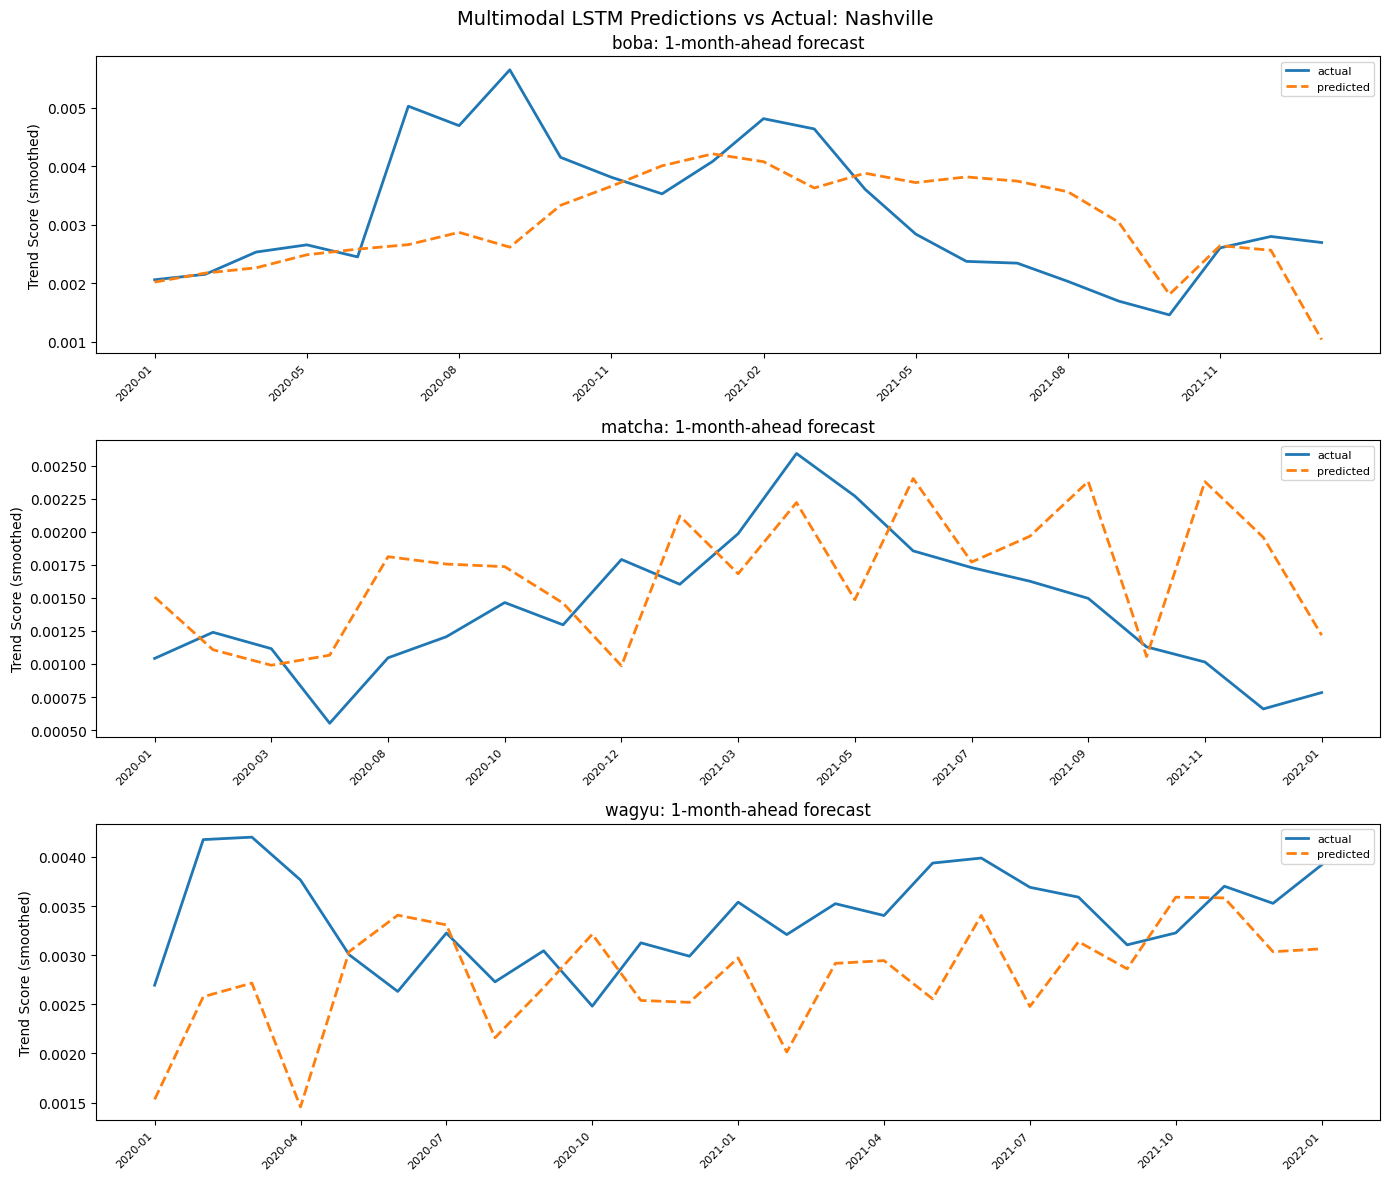

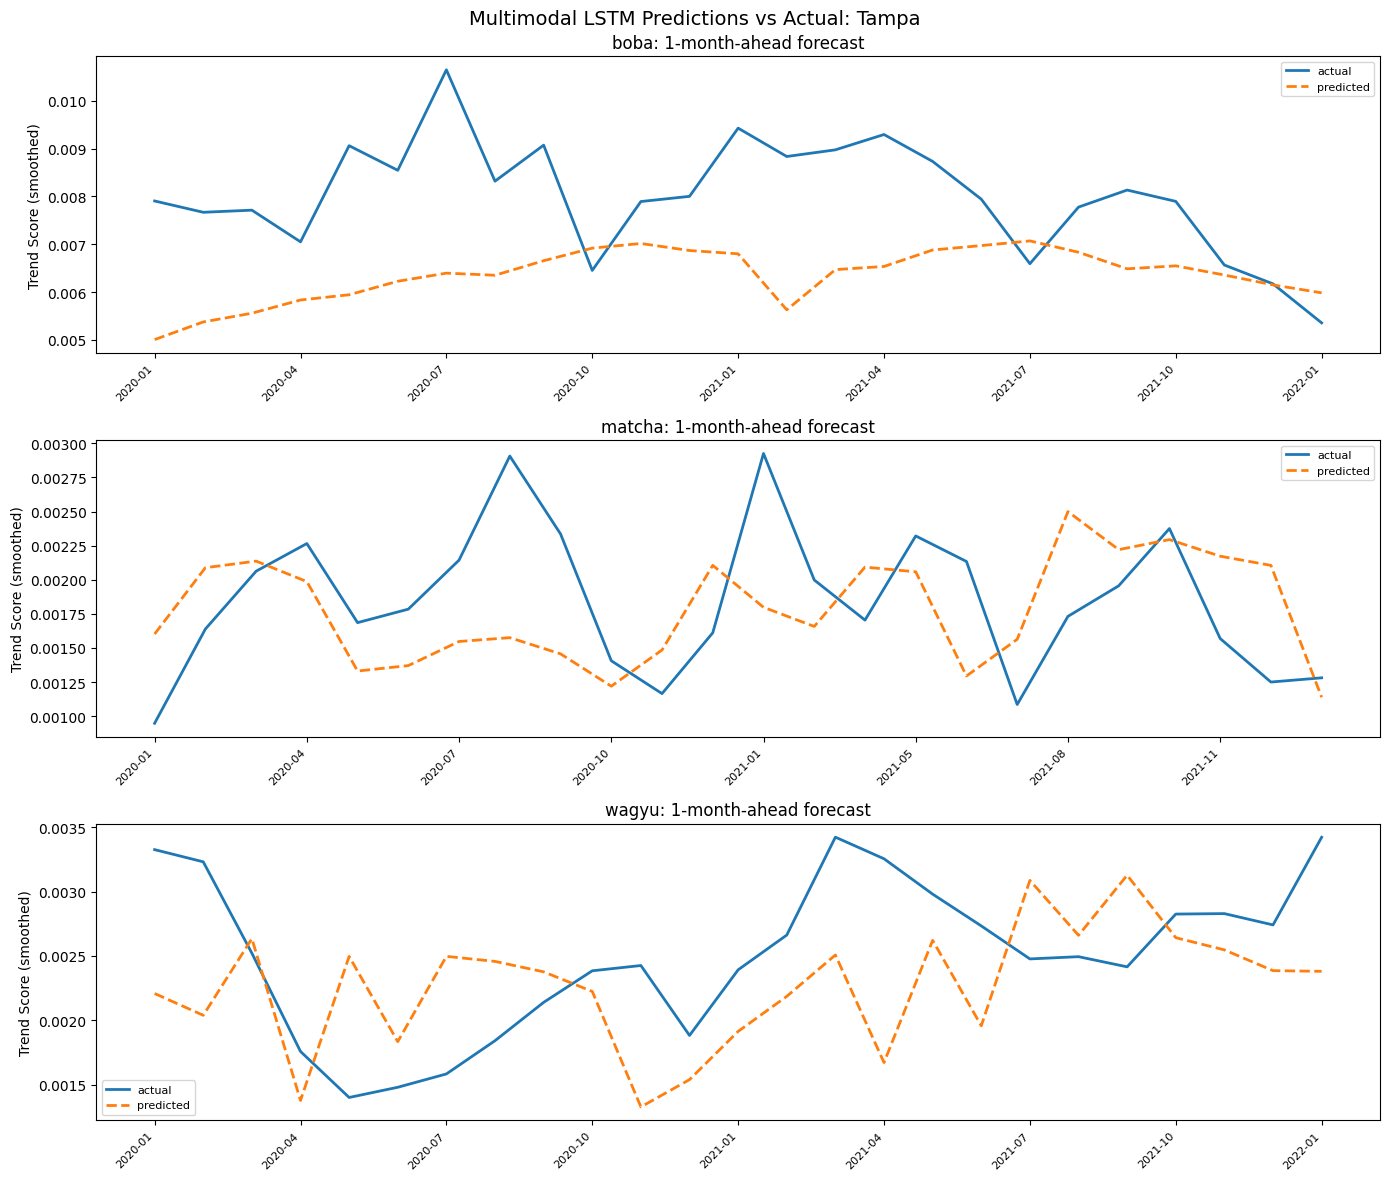

In [11]:
import matplotlib.pyplot as plt

keywords_to_plot = ["boba", "matcha", "wagyu"]
cities_to_plot = ["Philadelphia", "Nashville", "Tampa"]

for city_to_plot in cities_to_plot:
    fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 12), sharex=False)

    for ax, kw in zip(axes, keywords_to_plot):
        subset = results_df[
            (results_df["city"] == city_to_plot) &
            (results_df["keyword"] == kw) &
            (results_df["horizon"] == 1)
        ].sort_values("month").reset_index(drop=True)

        if subset.empty:
            ax.set_title(f"{kw} (no predictions)")
            continue

        ax.plot(range(len(subset)), subset["actual"], label="actual", linewidth=2)
        ax.plot(range(len(subset)), subset["predicted"], label="predicted", linewidth=2, linestyle="--")

        ax.set_title(f"{kw}: 1-month-ahead forecast")
        ax.set_ylabel("Trend Score (smoothed)")
        ax.legend(fontsize=8)

        n = len(subset)
        step = max(n // 8, 1)
        tick_positions = list(range(0, n, step))
        tick_labels = [subset["month"].iloc[i] for i in tick_positions]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    plt.suptitle(f"Multimodal LSTM Predictions vs Actual: {city_to_plot}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
save_cols = ["city", "month", "keyword", "horizon", "actual", "predicted", "abs_error"]
results_df[save_cols].to_parquet("multimodal_lstm_predictions.parquet", index=False)
files.download("multimodal_lstm_predictions.parquet")
print("Downloaded multimodal_lstm_predictions.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded multimodal_lstm_predictions.parquet
